EDA

In [1]:
import pandas as pd
df = pd.read_csv(r'F:\Downloads\Funnel Analysis Project\d2c_marketing_funnel_data.csv')

In [2]:
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())


   user_id  session_id        date    month   channel campaign_type  device  \
0   221958           1   8/16/2025  2025-08   Organic    New Launch  Mobile   
1   771155           2  12/16/2025  2025-12   Organic    Influencer  Mobile   
2   231932           3   7/17/2025  2025-07   Organic    Influencer  Mobile   
3   465838           4    7/4/2025  2025-07  Paid Ads      Discount  Mobile   
4   359178           5   8/10/2025  2025-08  Paid Ads    Influencer  Mobile   

   user_type     region visited_website viewed_product added_to_cart  \
0        New      Metro             Yes             No            No   
1        New  Non-Metro             Yes            Yes           Yes   
2        New  Non-Metro             Yes            Yes            No   
3  Returning      Metro             Yes            Yes           Yes   
4  Returning  Non-Metro             Yes             No            No   

  checkout_started purchase_completed discount_applied  order_value   revenue  
0           

Shape: (120000, 17)

Missing values per column:
 user_id               0
session_id            0
date                  0
month                 0
channel               0
campaign_type         0
device                0
user_type             0
region                0
visited_website       0
viewed_product        0
added_to_cart         0
checkout_started      0
purchase_completed    0
discount_applied      0
order_value           0
revenue               0
dtype: int64

Duplicate sessions (by session_id): 0

Data types:
 user_id                        int64
session_id                     int64
date                  datetime64[ns]
month                 datetime64[ns]
channel                     category
campaign_type               category
device                      category
user_type                   category
region                      category
visited_website                int64
viewed_product                 int64
added_to_cart                  int64
checkout_started               in

C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_15920\583021384.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby(group_col).agg(
C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_15920\583021384.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby(group_col).agg(
C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_15920\583021384.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  campaign_metrics

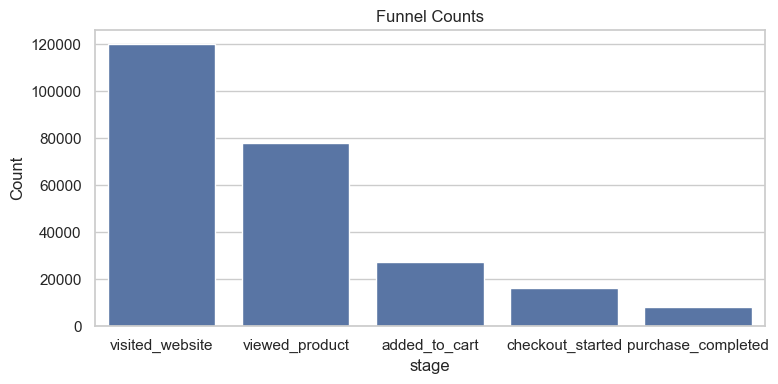

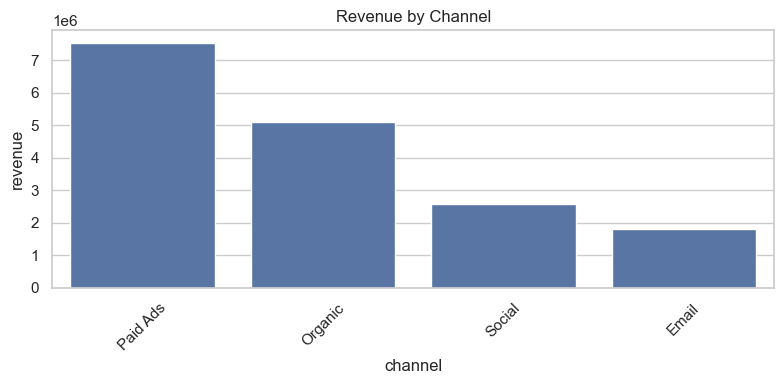

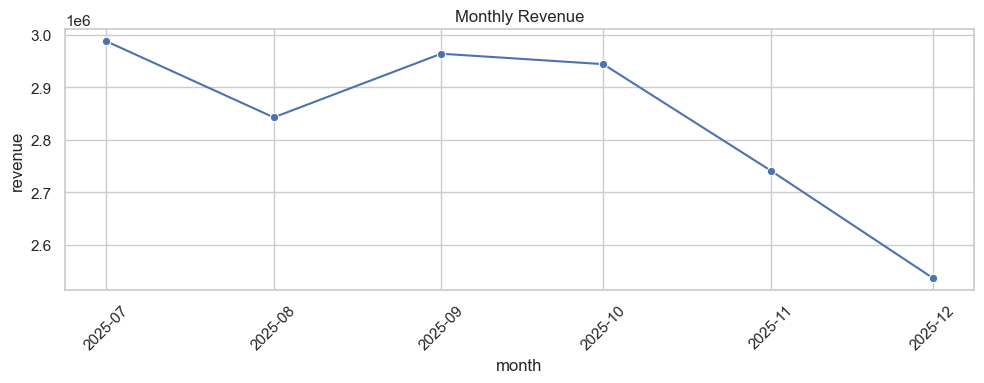

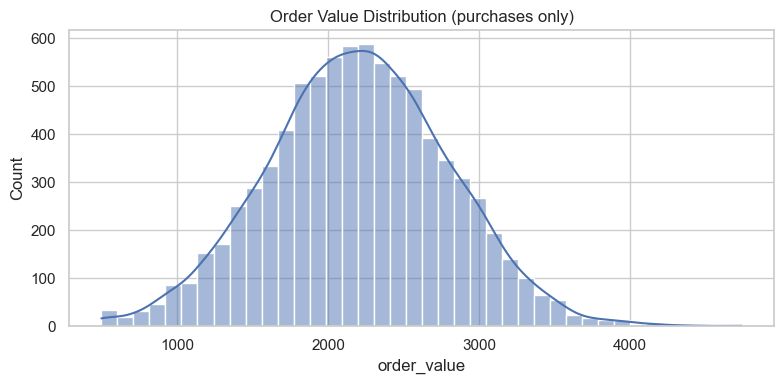

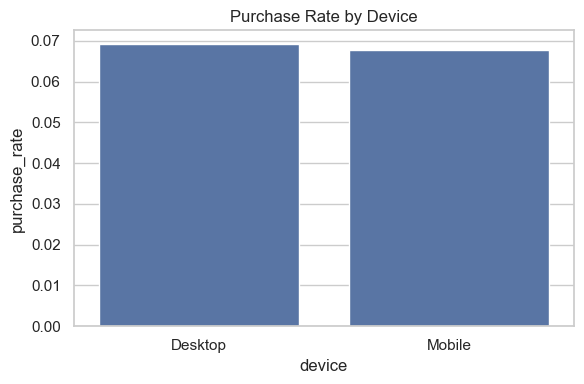

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# ---- 1) Basic dtype fixes ----
# parse dates
df['date'] = pd.to_datetime(df['date'], errors='coerce')
# month column appears like '2025-08' -> parse to period/month start
df['month'] = pd.to_datetime(df['month'], format='%Y-%m', errors='coerce')

# convert binary Yes/No columns to integers (0/1)
binary_cols = [
    'visited_website', 'viewed_product', 'added_to_cart',
    'checkout_started', 'purchase_completed', 'discount_applied'
]
for c in binary_cols:
    df[c] = df[c].map({'Yes': 1, 'No': 0}).astype('int64')

# categorical columns
cat_cols = ['channel', 'campaign_type', 'device', 'user_type', 'region']
for c in cat_cols:
    df[c] = df[c].astype('category')

# ensure numeric columns are numeric
df['order_value'] = pd.to_numeric(df['order_value'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

# ---- 2) Quick data health checks ----
print("Shape:", df.shape)
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate sessions (by session_id):", df.duplicated(subset=['session_id']).sum())

print("\nData types:\n", df.dtypes)
print("\nNumeric summary:\n", df[['order_value', 'revenue']].describe())

# ---- 3) Funnel summary (counts & conversion rates) ----
stages = ['visited_website', 'viewed_product', 'added_to_cart', 'checkout_started', 'purchase_completed']
counts = df[stages].sum().astype(int)
funnel = pd.DataFrame({
    'stage': stages,
    'count': counts.values,
    'rate_vs_total': (counts.values / len(df)).round(4)
})
print("\nFunnel summary:\n", funnel)

# ---- 4) Channel / Device / Month aggregations ----
def channel_device_month_agg(group_col):
    agg = df.groupby(group_col).agg(
        sessions=('session_id', 'count'),
        purchases=('purchase_completed', 'sum'),
        revenue=('revenue', 'sum')
    )
    agg['purchase_rate'] = (agg['purchases'] / agg['sessions']).fillna(0)
    agg['avg_order_value'] = (agg['revenue'] / agg['purchases']).replace([np.inf, -np.inf], np.nan)
    return agg.sort_values('revenue', ascending=False)

channel_metrics = channel_device_month_agg('channel')
device_metrics = channel_device_month_agg('device')
month_metrics = channel_device_month_agg('month')

print("\nChannel metrics:\n", channel_metrics)
print("\nDevice metrics:\n", device_metrics)
print("\nMonth metrics (sorted by month):\n", month_metrics.sort_index())

# ---- 5) Additional analyses ----
# top campaigns
campaign_metrics = df.groupby('campaign_type').agg(
    sessions=('session_id','count'),
    purchases=('purchase_completed','sum'),
    revenue=('revenue','sum')
)
campaign_metrics['purchase_rate'] = campaign_metrics['purchases'] / campaign_metrics['sessions']
campaign_metrics['avg_order_value'] = (campaign_metrics['revenue'] / campaign_metrics['purchases']).replace([np.inf, -np.inf], np.nan)
print("\nCampaign metrics:\n", campaign_metrics.sort_values('revenue', ascending=False))

# user_type & region breakdown
print("\nUser type counts:\n", df['user_type'].value_counts())
print("\nRegion counts:\n", df['region'].value_counts())

# correlation between numeric fields
print("\nCorrelation (order_value, revenue, purchase_completed):\n",
      df[['order_value','revenue','purchase_completed']].corr())

# ---- 6) Plots (quick visuals) ----
sns.set_theme(style='whitegrid')

# Funnel bar
plt.figure(figsize=(8,4))
sns.barplot(x='stage', y='count', data=funnel)
plt.title('Funnel Counts')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Revenue by channel
plt.figure(figsize=(8,4))
channel_rev = channel_metrics.reset_index()
sns.barplot(data=channel_rev, x='channel', y='revenue', order=channel_rev['channel'])
plt.title('Revenue by Channel')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Monthly revenue timeseries
plt.figure(figsize=(10,4))
month_rev = month_metrics.reset_index().sort_values('month')
sns.lineplot(data=month_rev, x='month', y='revenue', marker='o')
plt.title('Monthly Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Distribution of order_value for purchases
plt.figure(figsize=(8,4))
sns.histplot(df.loc[df['purchase_completed']==1, 'order_value'].dropna(), bins=40, kde=True)
plt.title('Order Value Distribution (purchases only)')
plt.tight_layout()
plt.show()

# Purchase rate by device
plt.figure(figsize=(6,4))
device_plot = device_metrics.reset_index()
sns.barplot(data=device_plot, x='device', y='purchase_rate')
plt.title('Purchase Rate by Device')
plt.tight_layout()
plt.show()

# ---- 7) Save cleaned snapshot (optional) ----
# df.to_csv('cleaned_funnel_data.csv', index=False)

# End of EDA cell

In [12]:
# ==========================================
# FUNNEL LOGIC VALIDATION
# ==========================================

stages = [
    'visited_website',
    'viewed_product',
    'added_to_cart',
    'checkout_started',
    'purchase_completed'
]

# Check impossible funnel transitions
invalid_product = (
    (df['viewed_product'] == 1) &
    (df['visited_website'] == 0)
).sum()

invalid_cart = (
    (df['added_to_cart'] == 1) &
    (df['viewed_product'] == 0)
).sum()

invalid_checkout = (
    (df['checkout_started'] == 1) &
    (df['added_to_cart'] == 0)
).sum()

invalid_purchase = (
    (df['purchase_completed'] == 1) &
    (df['checkout_started'] == 0)
).sum()

print("=== Funnel Logic Validation ===")

print(f"Product viewed without website visit: {invalid_product:,}")
print(f"Cart added without product view:      {invalid_cart:,}")
print(f"Checkout without cart:                {invalid_checkout:,}")
print(f"Purchase without checkout:            {invalid_purchase:,}")

# ==========================================
# REVENUE / ORDER VALUE VALIDATION
# ==========================================

print("=== Purchase vs Revenue Validation ===")

print(
    "Purchases:",
    df['purchase_completed'].sum()
)

print(
    "Rows with revenue > 0:",
    (df['revenue'] > 0).sum()
)

print(
    "Purchases with revenue = 0:",
    (
        (df['purchase_completed'] == 1) &
        (df['revenue'] == 0)
    ).sum()
)

print(
    "Non-purchases with revenue > 0:",
    (
        (df['purchase_completed'] == 0) &
        (df['revenue'] > 0)
    ).sum()
)

print("\nOrder value by purchase status:")
print(
    df.groupby('purchase_completed')['order_value']
      .agg(['count', 'mean', 'median', 'min', 'max'])
)

=== Funnel Logic Validation ===
Product viewed without website visit: 0
Cart added without product view:      0
Checkout without cart:                0
Purchase without checkout:            0
=== Purchase vs Revenue Validation ===
Purchases: 8181
Rows with revenue > 0: 8181
Purchases with revenue = 0: 0
Non-purchases with revenue > 0: 0

Order value by purchase status:
                     count         mean   median    min      max
purchase_completed                                              
0                   111819   499.000000   499.00  499.0   499.00
1                     8181  2199.955988  2198.04  499.0  4741.37


In [13]:
import pandas as pd
import numpy as np


# =========================================================
# REUSABLE FUNNEL ANALYSIS FUNCTION
# =========================================================

def generate_vertical_funnel(df, segment_col):
    """
    Generate funnel metrics for each segment within a given column.

    Parameters
    ----------
    df : pandas.DataFrame
        Cleaned funnel dataset.

    segment_col : str
        Column used for segmentation, e.g. 'device', 'channel',
        'campaign_type', 'user_type', or 'region'.

    Returns
    -------
    pandas.DataFrame
        Funnel metrics for every segment.
    """

    stages = [
        'visited_website',
        'viewed_product',
        'added_to_cart',
        'checkout_started',
        'purchase_completed'
    ]

    all_funnels = []

    for segment in df[segment_col].dropna().unique():

        # Filter data for the current segment
        segment_df = df[df[segment_col] == segment]

        # Count users reaching each funnel stage
        counts = segment_df[stages].sum().astype(int).values

        funnel = pd.DataFrame({
            'Segment': segment,
            'Stage': stages,
            'Users_Count': counts
        })

        # -------------------------------------------------
        # Overall conversion relative to initial traffic
        # -------------------------------------------------

        funnel['Overall_Conversion_%'] = (
            funnel['Users_Count'] /
            funnel['Users_Count'].iloc[0] *
            100
        ).round(2)

        # -------------------------------------------------
        # Stage-to-stage conversion
        # -------------------------------------------------

        funnel['Stage_to_Stage_Conversion_%'] = (
            funnel['Users_Count'] /
            funnel['Users_Count'].shift(1) *
            100
        ).fillna(100).round(2)

        # -------------------------------------------------
        # Stage drop-off
        # -------------------------------------------------

        funnel['Drop_off_Rate_%'] = (
            100 -
            funnel['Stage_to_Stage_Conversion_%']
        ).round(2)

        # -------------------------------------------------
        # Absolute users lost between stages
        # -------------------------------------------------

        funnel['Users_Lost'] = (
            funnel['Users_Count'].shift(1) -
            funnel['Users_Count']
        ).fillna(0).astype(int)

        all_funnels.append(funnel)

    return pd.concat(all_funnels, ignore_index=True)


# =========================================================
# DEVICE FUNNEL ANALYSIS
# =========================================================

device_funnel_df = generate_vertical_funnel(
    df,
    'device'
)


# =========================================================
# DISPLAY RESULTS
# =========================================================

for device in ['Mobile', 'Desktop']:

    print("\n" + "=" * 60)
    print(f"{device.upper()} FUNNEL ANALYSIS")
    print("=" * 60)

    device_result = (
        device_funnel_df[
            device_funnel_df['Segment'] == device
        ]
        .drop(columns='Segment')
    )

    print(
        device_result.to_string(index=False)
    )


MOBILE FUNNEL ANALYSIS
             Stage  Users_Count  Overall_Conversion_%  Stage_to_Stage_Conversion_%  Drop_off_Rate_%  Users_Lost
   visited_website        84006                100.00                       100.00             0.00           0
    viewed_product        54497                 64.87                        64.87            35.13       29509
     added_to_cart        19016                 22.64                        34.89            65.11       35481
  checkout_started        11341                 13.50                        59.64            40.36        7675
purchase_completed         5693                  6.78                        50.20            49.80        5648

DESKTOP FUNNEL ANALYSIS
             Stage  Users_Count  Overall_Conversion_%  Stage_to_Stage_Conversion_%  Drop_off_Rate_%  Users_Lost
   visited_website        35994                100.00                       100.00             0.00           0
    viewed_product        23373                 64.94  

In [14]:
import pandas as pd
import numpy as np

from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests


# =========================================================
# STATISTICAL SIGNIFICANCE TESTING
# MOBILE VS DESKTOP
# =========================================================

print("=" * 70)
print("STATISTICAL SIGNIFICANCE TEST: MOBILE VS DESKTOP")
print("=" * 70)


# =========================================================
# 1. OVERALL CONVERSION TEST
# =========================================================

mobile_df = df[df['device'] == 'Mobile']
desktop_df = df[df['device'] == 'Desktop']

mobile_sessions = len(mobile_df)
desktop_sessions = len(desktop_df)

mobile_purchases = mobile_df['purchase_completed'].sum()
desktop_purchases = desktop_df['purchase_completed'].sum()

mobile_rate = mobile_purchases / mobile_sessions
desktop_rate = desktop_purchases / desktop_sessions

counts_overall = np.array([
    mobile_purchases,
    desktop_purchases
])

nobs_overall = np.array([
    mobile_sessions,
    desktop_sessions
])

stat_overall, pval_overall = proportions_ztest(
    counts_overall,
    nobs_overall
)

absolute_difference = mobile_rate - desktop_rate
relative_difference = (
    (mobile_rate / desktop_rate) - 1
) * 100


print("\n--- Test 1: Overall Conversion ---")

print(f"Mobile Conversion   : {mobile_rate * 100:.2f}%")
print(f"Desktop Conversion  : {desktop_rate * 100:.2f}%")
print(f"Absolute Difference : {absolute_difference * 100:.2f} pp")
print(f"Relative Difference : {relative_difference:.2f}%")
print(f"Z-statistic         : {stat_overall:.4f}")
print(f"P-value             : {pval_overall:.4f}")

if pval_overall < 0.05:
    print(
        "Result              : Statistically Significant"
    )
else:
    print(
        "Result              : Not Statistically Significant"
    )


# =========================================================
# 2. STAGE-BY-STAGE TESTING
# =========================================================

stages = [
    'visited_website',
    'viewed_product',
    'added_to_cart',
    'checkout_started',
    'purchase_completed'
]

test_results = []

for i in range(len(stages) - 1):

    stage_from = stages[i]
    stage_to = stages[i + 1]

    # -----------------------------
    # Mobile
    # -----------------------------

    m_from = mobile_df[stage_from].sum()
    m_to = mobile_df[stage_to].sum()

    # -----------------------------
    # Desktop
    # -----------------------------

    d_from = desktop_df[stage_from].sum()
    d_to = desktop_df[stage_to].sum()

    # -----------------------------
    # Conversion rates
    # -----------------------------

    mobile_conversion = m_to / m_from
    desktop_conversion = d_to / d_from

    difference = mobile_conversion - desktop_conversion

    # -----------------------------
    # Two-proportion Z-test
    # -----------------------------

    counts = np.array([m_to, d_to])
    nobs = np.array([m_from, d_from])

    z_stat, p_value = proportions_ztest(
        counts,
        nobs
    )

    test_results.append({
        'Transition': (
            f"{stage_from} → {stage_to}"
        ),
        'Mobile_Rate_%': round(
            mobile_conversion * 100, 2
        ),
        'Desktop_Rate_%': round(
            desktop_conversion * 100, 2
        ),
        'Difference_pp': round(
            difference * 100, 2
        ),
        'Z_statistic': round(
            z_stat, 4
        ),
        'p_value': p_value
    })


results_df = pd.DataFrame(test_results)


# =========================================================
# 3. MULTIPLE TESTING CORRECTION
# =========================================================

results_df['Adjusted_p_value'] = multipletests(
    results_df['p_value'],
    method='holm'
)[1]

results_df['Significant'] = np.where(
    results_df['Adjusted_p_value'] < 0.05,
    'Yes',
    'No'
)

results_df['p_value'] = results_df['p_value'].round(4)
results_df['Adjusted_p_value'] = (
    results_df['Adjusted_p_value'].round(4)
)


# =========================================================
# 4. DISPLAY RESULTS
# =========================================================

print("\n--- Test 2: Stage-by-Stage Analysis ---")

print(
    results_df[
        [
            'Transition',
            'Mobile_Rate_%',
            'Desktop_Rate_%',
            'Difference_pp',
            'p_value',
            'Adjusted_p_value',
            'Significant'
        ]
    ].to_string(index=False)
)

print("\n" + "=" * 70)

STATISTICAL SIGNIFICANCE TEST: MOBILE VS DESKTOP

--- Test 1: Overall Conversion ---
Mobile Conversion   : 6.78%
Desktop Conversion  : 6.91%
Absolute Difference : -0.14 pp
Relative Difference : -1.96%
Z-statistic         : -0.8525
P-value             : 0.3939
Result              : Not Statistically Significant

--- Test 2: Stage-by-Stage Analysis ---
                           Transition  Mobile_Rate_%  Desktop_Rate_%  Difference_pp  p_value  Adjusted_p_value Significant
     visited_website → viewed_product          64.87           64.94          -0.06   0.8338               1.0          No
       viewed_product → added_to_cart          34.89           34.83           0.07   0.8570               1.0          No
     added_to_cart → checkout_started          59.64           60.11          -0.47   0.4680               1.0          No
checkout_started → purchase_completed          50.20           50.85          -0.65   0.4474               1.0          No



In [16]:
import pandas as pd
import numpy as np


# =========================================================
# STEP 4: CHANNEL FUNNEL ANALYSIS
# =========================================================

print("=" * 70)
print("STEP 4: CHANNEL FUNNEL ANALYSIS")
print("=" * 70)


# =========================================================
# 1. GENERATE FUNNEL BY CHANNEL
# =========================================================

channel_funnel_df = generate_vertical_funnel(
    df,
    'channel'
)


# =========================================================
# 2. CHANNEL FINANCIAL METRICS
# =========================================================

channel_financials = (
    df.groupby('channel')
      .agg(
          Sessions=('session_id', 'count'),
          Purchases=('purchase_completed', 'sum'),
          Revenue=('revenue', 'sum')
      )
)

# Overall purchase conversion
channel_financials['Conversion_%'] = (
    channel_financials['Purchases'] /
    channel_financials['Sessions'] *
    100
).round(2)

# Average Order Value
channel_financials['AOV'] = (
    channel_financials['Revenue'] /
    channel_financials['Purchases']
).round(2)

# Revenue generated per session
channel_financials['Revenue_per_Session'] = (
    channel_financials['Revenue'] /
    channel_financials['Sessions']
).round(2)


# Sort by total revenue
channel_financials = channel_financials.sort_values(
    'Revenue',
    ascending=False
)


# =========================================================
# 3. CHANNEL SUMMARY
# =========================================================

print("\n--- Channel Financial Summary ---")

print(
    channel_financials[
        [
            'Sessions',
            'Purchases',
            'Conversion_%',
            'Revenue',
            'AOV',
            'Revenue_per_Session'
        ]
    ].to_string()
)


# =========================================================
# 4. DETAILED FUNNEL FOR EACH CHANNEL
# =========================================================

for channel in channel_financials.index:

    print("\n" + "=" * 70)
    print(f"CHANNEL: {channel.upper()}")
    print("=" * 70)

    financials = channel_financials.loc[channel]

    print(
        f"Revenue: ${financials['Revenue']:,.2f}"
    )

    print(
        f"AOV: ${financials['AOV']:,.2f}"
    )

    print(
        f"Revenue / Session: "
        f"${financials['Revenue_per_Session']:,.2f}"
    )

    print()

    channel_result = (
        channel_funnel_df[
            channel_funnel_df['Segment'] == channel
        ]
        .drop(columns='Segment')
    )

    print(
        channel_result.to_string(index=False)
    )

STEP 4: CHANNEL FUNNEL ANALYSIS

--- Channel Financial Summary ---
          Sessions  Purchases  Conversion_%      Revenue      AOV  Revenue_per_Session
channel                                                                               
Paid Ads     53891       3619          6.72  7536147.080  2082.38               139.84
Organic      35946       2448          6.81  5090708.447  2079.54               141.62
Social       18071       1230          6.81  2578443.312  2096.30               142.68
Email        12092        884          7.31  1811300.315  2048.98               149.79

CHANNEL: PAID ADS
Revenue: $7,536,147.08
AOV: $2,082.38
Revenue / Session: $139.84

             Stage  Users_Count  Overall_Conversion_%  Stage_to_Stage_Conversion_%  Drop_off_Rate_%  Users_Lost
   visited_website        53891                100.00                       100.00             0.00           0
    viewed_product        35011                 64.97                        64.97            35.03   

C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_15920\2136018311.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('channel')


In [18]:
import pandas as pd
import numpy as np
import itertools

from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests


# =========================================================
# STEP 5 — CHANNEL STATISTICAL SIGNIFICANCE
# =========================================================

print("=" * 70)
print("STEP 5 — CHANNEL STATISTICAL SIGNIFICANCE")
print("=" * 70)


# =========================================================
# TEST A — OVERALL CHANNEL × PURCHASE
# =========================================================

contingency_overall = pd.crosstab(
    df['channel'],
    df['purchase_completed']
)

chi2_stat, p_overall, dof, expected = chi2_contingency(
    contingency_overall
)

# Cramer's V
n = contingency_overall.to_numpy().sum()
min_dimension = min(
    contingency_overall.shape[0] - 1,
    contingency_overall.shape[1] - 1
)

cramers_v = np.sqrt(
    (chi2_stat / n) / min_dimension
)

print("\n--- TEST A: Overall Channel × Purchase ---")

print(
    f"Chi-Square Statistic : {chi2_stat:.4f}"
)

print(
    f"Degrees of Freedom   : {dof}"
)

print(
    f"P-value              : {p_overall:.4f}"
)

print(
    f"Cramer's V           : {cramers_v:.4f}"
)

if p_overall < 0.05:
    print(
        "Result: Statistically significant association."
    )
else:
    print(
        "Result: No statistically significant association."
    )


# =========================================================
# TEST B — PAIRWISE COMPARISONS
# Only run if overall test is significant
# =========================================================

if p_overall < 0.05:

    print(
        "\n--- TEST B: Pairwise Channel Comparisons ---"
    )

    channels = df['channel'].dropna().unique()

    pairs = list(
        itertools.combinations(channels, 2)
    )

    pairwise_results = []

    raw_pvalues = []

    for c1, c2 in pairs:

        df1 = df[df['channel'] == c1]
        df2 = df[df['channel'] == c2]

        success = np.array([
            df1['purchase_completed'].sum(),
            df2['purchase_completed'].sum()
        ])

        observations = np.array([
            len(df1),
            len(df2)
        ])

        z_stat, p_value = proportions_ztest(
            success,
            observations
        )

        raw_pvalues.append(p_value)

        pairwise_results.append({
            'Channel_1': c1,
            'Channel_2': c2,
            'Rate_1_%': (
                success[0] /
                observations[0] *
                100
            ),
            'Rate_2_%': (
                success[1] /
                observations[1] *
                100
            ),
            'Raw_p_value': p_value
        })

    reject, adjusted_pvalues, _, _ = multipletests(
        raw_pvalues,
        alpha=0.05,
        method='holm'
    )

    for i in range(len(pairwise_results)):

        pairwise_results[i][
            'Holm_Adjusted_p'
        ] = adjusted_pvalues[i]

        pairwise_results[i][
            'Significant'
        ] = (
            'Yes'
            if reject[i]
            else 'No'
        )

    pairwise_df = pd.DataFrame(
        pairwise_results
    )

    pairwise_df['Rate_1_%'] = (
        pairwise_df['Rate_1_%'].round(2)
    )

    pairwise_df['Rate_2_%'] = (
        pairwise_df['Rate_2_%'].round(2)
    )

    pairwise_df['Raw_p_value'] = (
        pairwise_df['Raw_p_value'].round(4)
    )

    pairwise_df['Holm_Adjusted_p'] = (
        pairwise_df['Holm_Adjusted_p'].round(4)
    )

    print(
        pairwise_df.to_string(index=False)
    )

else:

    print(
        "\n--- TEST B SKIPPED ---"
    )

    print(
        "Overall channel association was "
        "not statistically significant."
    )


# =========================================================
# TEST C — BOTTLENECK ANALYSIS
# =========================================================

print(
    "\n--- TEST C: Stage-Specific Channel Analysis ---"
)


bottleneck_tests = []

transitions = [
    ('viewed_product', 'added_to_cart'),
    ('checkout_started', 'purchase_completed')
]


for stage_from, stage_to in transitions:

    eligible = df[
        df[stage_from] == 1
    ]

    contingency = pd.crosstab(
        eligible['channel'],
        eligible[stage_to]
    )

    chi2, p_value, dof, expected = (
        chi2_contingency(contingency)
    )

    bottleneck_tests.append({

        'Transition':
            f"{stage_from} → {stage_to}",

        'Chi_Square':
            round(chi2, 4),

        'p_value':
            round(p_value, 4),

        'Significant':
            'Yes'
            if p_value < 0.05
            else 'No'
    })


bottleneck_df = pd.DataFrame(
    bottleneck_tests
)

print(
    bottleneck_df.to_string(index=False)
)


print("\n" + "=" * 70)

STEP 5 — CHANNEL STATISTICAL SIGNIFICANCE

--- TEST A: Overall Channel × Purchase ---
Chi-Square Statistic : 5.5192
Degrees of Freedom   : 3
P-value              : 0.1375
Cramer's V           : 0.0068
Result: No statistically significant association.

--- TEST B SKIPPED ---
Overall channel association was not statistically significant.

--- TEST C: Stage-Specific Channel Analysis ---
                           Transition  Chi_Square  p_value Significant
       viewed_product → added_to_cart      7.7851   0.0507          No
checkout_started → purchase_completed      1.2147   0.7495          No



In [21]:
import pandas as pd
import numpy as np


# =========================================================
# STEP 6 — CAMPAIGN FUNNEL ANALYSIS
# =========================================================

print("=" * 70)
print("STEP 6 — CAMPAIGN FUNNEL ANALYSIS")
print("=" * 70)


# =========================================================
# 1. GENERATE FUNNEL
# =========================================================

campaign_funnel_df = generate_vertical_funnel(
    df,
    'campaign_type'
)


# =========================================================
# 2. FINANCIAL METRICS
# =========================================================

campaign_financials = (
    df.groupby('campaign_type')
      .agg(
          Sessions=('session_id', 'count'),
          Purchases=('purchase_completed', 'sum'),
          Revenue=('revenue', 'sum')
      )
)


# Overall Conversion
campaign_financials['Conversion_%'] = (
    campaign_financials['Purchases'] /
    campaign_financials['Sessions'] *
    100
).round(2)


# AOV
campaign_financials['AOV'] = (
    campaign_financials['Revenue'] /
    campaign_financials['Purchases']
).round(2)


# Revenue per Session
campaign_financials['Revenue_per_Session'] = (
    campaign_financials['Revenue'] /
    campaign_financials['Sessions']
).round(2)


# Sort by Revenue
campaign_financials = (
    campaign_financials
    .sort_values(
        'Revenue',
        ascending=False
    )
)


# =========================================================
# 3. FINANCIAL SUMMARY
# =========================================================

print("\n--- Campaign Financial Summary ---")

print(
    campaign_financials[
        [
            'Sessions',
            'Purchases',
            'Conversion_%',
            'Revenue',
            'AOV',
            'Revenue_per_Session'
        ]
    ].to_string()
)


# =========================================================
# 4. DETAILED FUNNEL
# =========================================================

for campaign in campaign_financials.index:

    print("\n" + "=" * 70)
    print(
        f"CAMPAIGN: {campaign.upper()}"
    )
    print("=" * 70)

    metrics = campaign_financials.loc[
        campaign
    ]

    print(
        f"Revenue: ${metrics['Revenue']:,.2f}"
    )

    print(
        f"Conversion: {metrics['Conversion_%']:.2f}%"
    )

    print(
        f"AOV: ${metrics['AOV']:,.2f}"
    )

    print(
        f"Revenue / Session: "
        f"${metrics['Revenue_per_Session']:,.2f}"
    )

    print()

    campaign_result = (
        campaign_funnel_df[
            campaign_funnel_df['Segment'] == campaign
        ]
        .drop(columns='Segment')
    )

    print(
        campaign_result.to_string(index=False)
    )

STEP 6 — CAMPAIGN FUNNEL ANALYSIS

--- Campaign Financial Summary ---
               Sessions  Purchases  Conversion_%      Revenue      AOV  Revenue_per_Session
campaign_type                                                                              
Discount          60121       4107          6.83  8526583.032  2076.11               141.82
New Launch        36064       2448          6.79  5122705.322  2092.61               142.04
Influencer        23815       1626          6.83  3367310.800  2070.92               141.39

CAMPAIGN: DISCOUNT
Revenue: $8,526,583.03
Conversion: 6.83%
AOV: $2,076.11
Revenue / Session: $141.82

             Stage  Users_Count  Overall_Conversion_%  Stage_to_Stage_Conversion_%  Drop_off_Rate_%  Users_Lost
   visited_website        60121                100.00                       100.00             0.00           0
    viewed_product        38950                 64.79                        64.79            35.21       21171
     added_to_cart        1354

C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_15920\1825221860.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('campaign_type')


In [22]:
import pandas as pd
from scipy.stats import chi2_contingency

print("="*70)
print("STEP 7: CAMPAIGN STATISTICAL SIGNIFICANCE (CHI-SQUARE)")
print("="*70)

# ---------------------------------------------------------
# Test A: Overall Chi-Square Test (Campaign x Purchase)
# ---------------------------------------------------------
contingency_campaign_overall = pd.crosstab(df['campaign_type'], df['purchase_completed'])
chi2_stat_a, p_overall_a, dof_a, _ = chi2_contingency(contingency_campaign_overall)

print("\n--- TEST A: Overall Campaign Conversion ---")
print("Question: Is purchase conversion associated with campaign type?")
print(f"Chi-Square Statistic: {chi2_stat_a:.2f}")
print(f"p-value: {p_overall_a:.4e}")

if p_overall_a < 0.05:
    print("Result: Significant. Campaign type statistically impacts overall purchase conversion.\n")
else:
    print("Result: Not Significant. Overall conversion does not statistically differ by campaign type.\n")


# ---------------------------------------------------------
# Test B: Bottleneck 1 (Product -> Cart)
# ---------------------------------------------------------
# الفلتر: نختبر فقط المستخدمين الذين شاهدوا المنتج
df_product_viewers = df[df['viewed_product'] == 1]
contingency_campaign_cart = pd.crosstab(df_product_viewers['campaign_type'], df_product_viewers['added_to_cart'])
chi2_stat_b, p_cart_b, dof_b, _ = chi2_contingency(contingency_campaign_cart)

print("--- TEST B: Primary Bottleneck (Product -> Cart) ---")
print("Question: Does campaign type significantly affect the biggest funnel bottleneck?")
print(f"Chi-Square Statistic: {chi2_stat_b:.2f}")
print(f"p-value: {p_cart_b:.4e}")

if p_cart_b < 0.05:
    print("Result: Significant. The drop-off at this stage varies significantly by campaign.\n")
else:
    print("Result: Not Significant. The drop-off at this stage is similar across all campaigns.\n")


# ---------------------------------------------------------
# Test C: Secondary Bottleneck (Checkout -> Purchase)
# ---------------------------------------------------------
# الفلتر: نختبر فقط المستخدمين الذين وصلوا لمرحلة الدفع
df_checkout_starters = df[df['checkout_started'] == 1]
contingency_campaign_purchase = pd.crosstab(df_checkout_starters['campaign_type'], df_checkout_starters['purchase_completed'])
chi2_stat_c, p_purchase_c, dof_c, _ = chi2_contingency(contingency_campaign_purchase)

print("--- TEST C: Secondary Bottleneck (Checkout -> Purchase) ---")
print("Question: Does campaign type significantly affect the checkout completion rate?")
print(f"Chi-Square Statistic: {chi2_stat_c:.2f}")
print(f"p-value: {p_purchase_c:.4e}")

if p_purchase_c < 0.05:
    print("Result: Significant. Checkout completion varies significantly by campaign.\n")
else:
    print("Result: Not Significant. Checkout completion is similar across all campaigns.\n")

print("="*70)

STEP 7: CAMPAIGN STATISTICAL SIGNIFICANCE (CHI-SQUARE)

--- TEST A: Overall Campaign Conversion ---
Question: Is purchase conversion associated with campaign type?
Chi-Square Statistic: 0.07
p-value: 9.6498e-01
Result: Not Significant. Overall conversion does not statistically differ by campaign type.

--- TEST B: Primary Bottleneck (Product -> Cart) ---
Question: Does campaign type significantly affect the biggest funnel bottleneck?
Chi-Square Statistic: 2.70
p-value: 2.5896e-01
Result: Not Significant. The drop-off at this stage is similar across all campaigns.

--- TEST C: Secondary Bottleneck (Checkout -> Purchase) ---
Question: Does campaign type significantly affect the checkout completion rate?
Chi-Square Statistic: 1.05
p-value: 5.9027e-01
Result: Not Significant. Checkout completion is similar across all campaigns.



In [23]:
df.to_csv(
    'ecommerce_funnel_cleaned.csv',
    index=False
)